In [1]:
import pandas as pd

# 1. Load the FAO Data (Yield and Production)
fao_df = pd.read_csv('FAO DATA SET 2.csv')

# 2. Load the Crop Recommendation Data (Soil and Weather)
crop_env_df = pd.read_csv('DATA SET2(crop recomendation).EDIT.csv')

# Verify the data is loaded by printing the first few rows
print("FAO Data Loaded:")
print(fao_df.head())

print("\nCrop Recommendation Data Loaded:")
print(crop_env_df.head())

FAO Data Loaded:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   
2  

In [2]:
# Filter the FAO dataset for Area = 'India' and Element = 'Yield'
fao_india_yield = fao_df[(fao_df['Area'] == 'India') & (fao_df['Element'] == 'Yield')]
# Display the result
print("✅ Successfully filtered for India and Yield records.")
display(fao_india_yield.head())

✅ Successfully filtered for India and Yield records.


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,kg/ha,484.0,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,430.3,A,Official figure,NaN
7,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,kg/ha,296.8,A,Official figure,NaN
10,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2003,2003,kg/ha,534.5,A,Official figure,NaN
13,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2004,2004,kg/ha,553.1,A,Official figure,NaN


✅ Data filtered! Found 18 out of 18 crops in the dataset.


C:\Users\ravik\AppData\Local\Temp\ipykernel_24392\4200484099.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_yields.values, y=avg_yields.index, palette='magma')


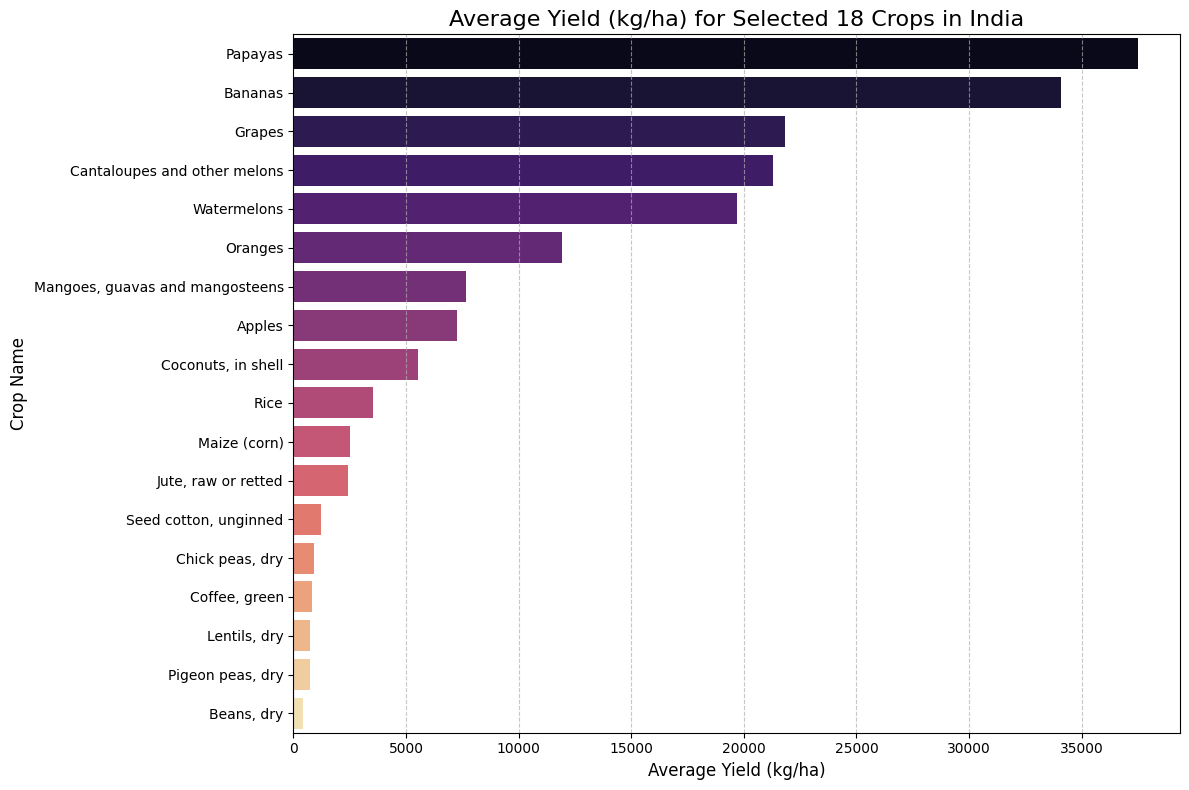

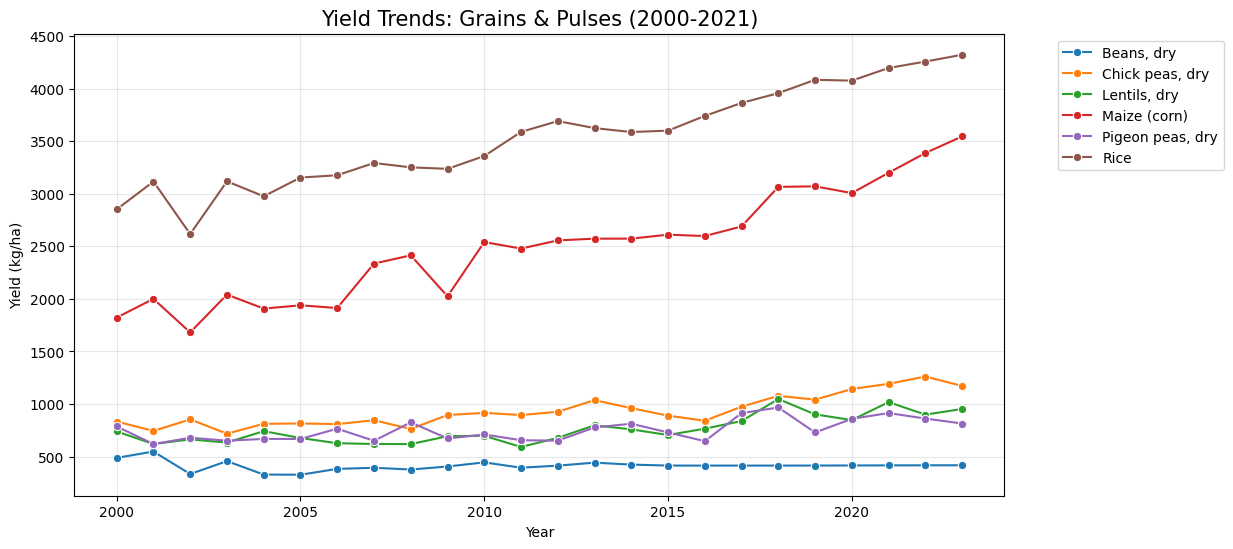

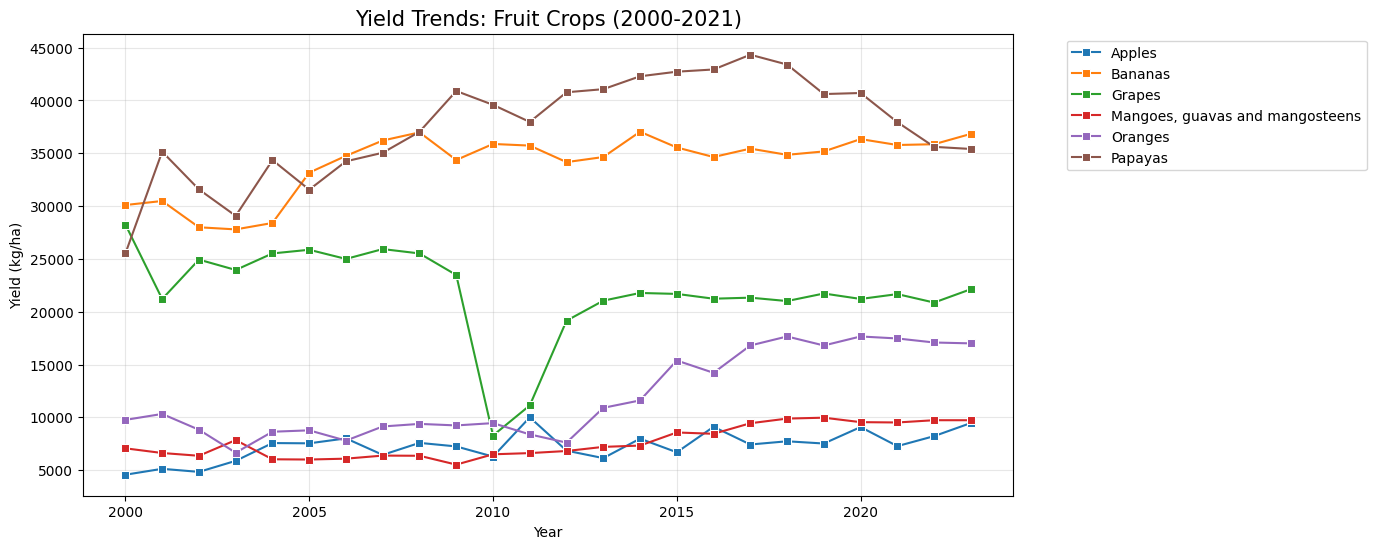

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND FILTER DATA
fao_df = pd.read_csv('FAO DATA SET 2.csv')

# Filter for India and Yield
fao_india = fao_df[(fao_df['Area'] == 'India') & (fao_df['Element'] == 'Yield')]
fao_india = fao_india[['Item', 'Year', 'Value']].rename(columns={'Item': 'Crop', 'Value': 'Yield_Value'})

# 2. DEFINE YOUR SPECIFIC 18 CROPS
my_crops = [
    'Rice', 'Maize (corn)', 'Chick peas, dry', 'Pigeon peas, dry', 'Beans, dry', 
    'Lentils, dry', 'Bananas', 'Mangoes, guavas and mangosteens', 'Grapes', 
    'Watermelons', 'Cantaloupes and other melons', 'Apples', 'Oranges', 
    'Papayas', 'Coconuts, in shell', 'Seed cotton, unginned', 
    'Jute, raw or retted', 'Coffee, green'
]

# Filter the data for only these 18 crops
eda_data = fao_india[fao_india['Crop'].isin(my_crops)]

print(f"✅ Data filtered! Found {eda_data['Crop'].nunique()} out of 18 crops in the dataset.")

# --- EDA TASK 1: Average Yield Comparison (Bar Chart) ---
plt.figure(figsize=(12, 8))
avg_yields = eda_data.groupby('Crop')['Yield_Value'].mean().sort_values(ascending=False)
sns.barplot(x=avg_yields.values, y=avg_yields.index, palette='magma')
plt.title('Average Yield (kg/ha) for Selected 18 Crops in India', fontsize=16)
plt.xlabel('Average Yield (kg/ha)', fontsize=12)
plt.ylabel('Crop Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- EDA TASK 2: Yield Trend for Grains (First 6 crops) ---
# Since plotting all 18 on one line chart is too crowded, let's look at the main grains first
grains = ['Rice', 'Maize (corn)', 'Chick peas, dry', 'Pigeon peas, dry', 'Beans, dry', 'Lentils, dry']
grain_data = eda_data[eda_data['Crop'].isin(grains)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=grain_data, x='Year', y='Yield_Value', hue='Crop', marker='o')
plt.title('Yield Trends: Grains & Pulses (2000-2021)', fontsize=15)
plt.ylabel('Yield (kg/ha)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --- EDA TASK 3: Yield Trend for Fruits (Next set of crops) ---
fruits = ['Bananas', 'Mangoes, guavas and mangosteens', 'Grapes', 'Apples', 'Oranges', 'Papayas']
fruit_data = eda_data[eda_data['Crop'].isin(fruits)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=fruit_data, x='Year', y='Yield_Value', hue='Crop', marker='s')
plt.title('Yield Trends: Fruit Crops (2000-2021)', fontsize=15)
plt.ylabel('Yield (kg/ha)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
import pandas as pd
import os

# 1. Load the data
file_name = 'FAOSTAT-DATA.csv'

if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    
    # 2. Clean column names (removes hidden spaces like " Element ")
    df.columns = df.columns.str.strip()
    
    # 3. Clean the data inside the 'Element' column (removes hidden spaces)
    if 'Element' in df.columns:
        df['Element'] = df['Element'].astype(str).str.strip()
        
        # 4. Filter to keep ONLY Yield
        # This removes "Area harvested" and "Production" automatically
        yield_df = df[df['Element'] == 'Yield'].copy()
        
        # Show results
        print(f"Success! Kept {len(yield_df)} rows of Yield data.")
        print(yield_df.head())
        
        # 5. Save the cleaned file
        yield_df.to_csv('FAOSTAT_Yield_Only.csv', index=False)
        print("File saved as: FAOSTAT_Yield_Only.csv")
    else:
        print("Error: Could not find the 'Element' column. Check the column names below:")
        print(df.columns.tolist())
else:
    print(f"Error: The file '{file_name}' was not found in this folder: {os.getcwd()}")

Success! Kept 1893 rows of Yield data.
   Domain Code                        Domain  Area Code (M49)   Area  \
1          QCL  Crops and livestock products              356  India   
4          QCL  Crops and livestock products              356  India   
7          QCL  Crops and livestock products              356  India   
10         QCL  Crops and livestock products              356  India   
13         QCL  Crops and livestock products              356  India   

    Element Code Element  Item Code (CPC)  \
1           5412   Yield           1654.0   
4           5412   Yield           1654.0   
7           5412   Yield           1654.0   
10          5412   Yield           1654.0   
13          5412   Yield           1654.0   

                                                 Item  Year Code  Year   Unit  \
1   Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   
4   Anise, badian, coriander, cumin, caraway, fenn...       2001  2001  kg/ha   
7   Anise, bad

In [5]:
import pandas as pd

# 1. LOAD THE DATASETS
# Ensure these filenames match your local folder exactly
fao_df = pd.read_csv('FAO DATA SET 2.csv')
crop_rec_df = pd.read_csv('DATA SET2(crop recomendation).EDIT.csv')

# 2. FILTER FAO DATA (India and Production only)
# This removes 'Area harvested' and 'Yield' automatically
fao_production = fao_df[(fao_df['Area'] == 'India') & (fao_df['Element'] == 'Production')].copy()

# 3. DEFINE YOUR 18 SPECIFIC CROPS
my_crops = [
    'Rice', 'Maize (corn)', 'Chick peas, dry', 'Pigeon peas, dry', 'Beans, dry', 
    'Lentils, dry', 'Bananas', 'Mangoes, guavas and mangosteens', 'Grapes', 
    'Watermelons', 'Cantaloupes and other melons', 'Apples', 'Oranges', 
    'Papayas', 'Coconuts, in shell', 'Seed cotton, unginned', 
    'Jute, raw or retted', 'Coffee, green'
]

# Filter FAO for these crops
fao_filtered = fao_production[fao_production['Item'].isin(my_crops)]

# 4. PREPARE RECOMMENDATION DATA
# We calculate the average (mean) per crop label so each crop has one set of conditions
env_avg = crop_rec_df.groupby('label').mean(numeric_only=True).reset_index()

# 5. MERGE DATASETS (Inner Join)
# Item (from FAO) matches label (from Recommendation)
merged_df = pd.merge(fao_filtered, env_avg, left_on='Item', right_on='label', how='inner')

# 6. KEEP ONLY THE REQUESTED COLUMNS
# Keeping the exact naming found in your datasets
cols_to_keep = ['Element','N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
final_production_df = merged_df[cols_to_keep]

# 7. SAVE AND VIEW
final_production_df.to_csv('production_merged_data.csv', index=False)

print("✅ Merging complete!")
print(f"Rows retained: {len(final_production_df)}")
display(final_production_df.head())

✅ Merging complete!
Rows retained: 432


,Element,N,P,K,temperature,humidity,ph,rainfall,label
0,Production,20.8,134.22,199.89,22.630942,92.333383,5.929663,112.654779,Apples
1,Production,20.8,134.22,199.89,22.630942,92.333383,5.929663,112.654779,Apples
2,Production,20.8,134.22,199.89,22.630942,92.333383,5.929663,112.654779,Apples
3,Production,20.8,134.22,199.89,22.630942,92.333383,5.929663,112.654779,Apples
4,Production,20.8,134.22,199.89,22.630942,92.333383,5.929663,112.654779,Apples


--- Data Quality Check ---
Null Values per column:
Element        0
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rain fall      0
label          0
dtype: int64

Number of duplicate rows: 6

Cleaning Complete:
- Rows before cleaning: 426
- Rows after removing outliers: 344


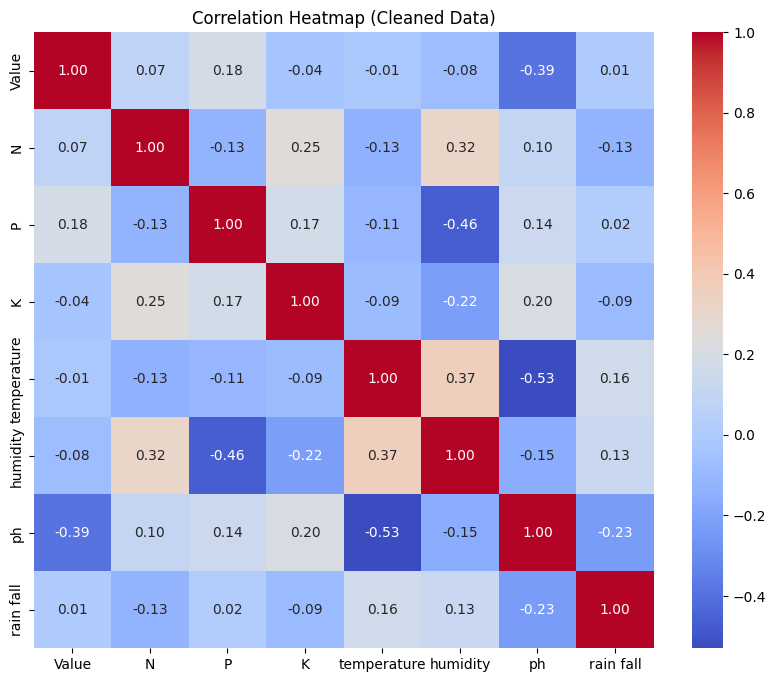

C:\Users\ravik\AppData\Local\Temp\ipykernel_24392\219404265.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_prod.values, y=mean_prod.index, palette='viridis')


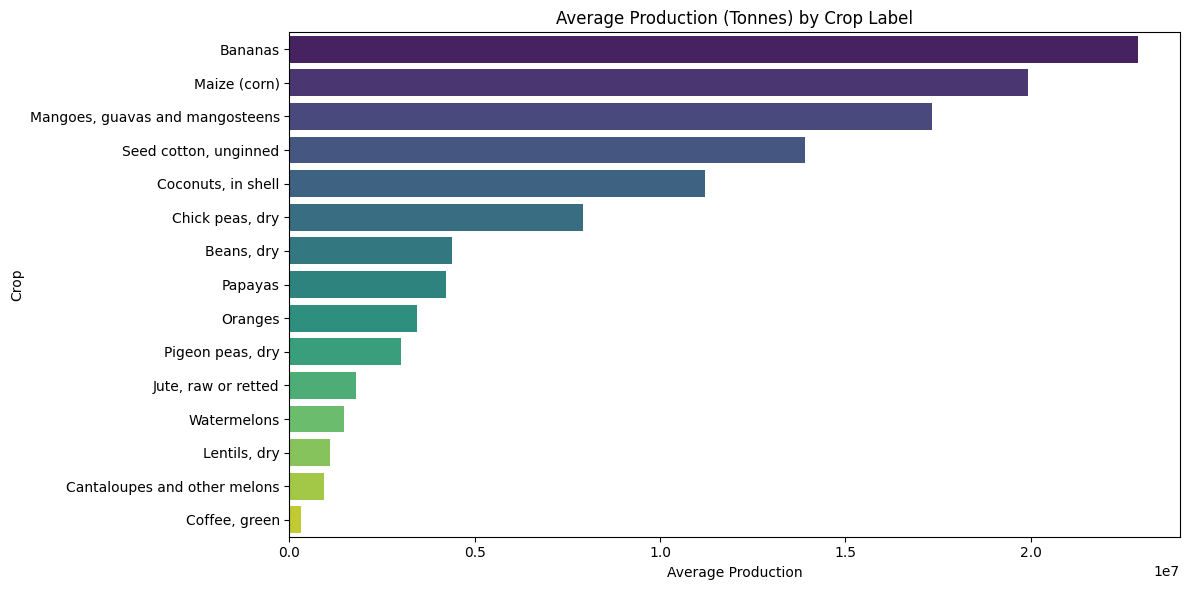

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the merged data
# (Ensure you use the filename created in the previous step)
df = pd.read_csv('production_dataset.csv')

# 2. Print Nulls & Duplicates
print("--- Data Quality Check ---")
print(f"Null Values per column:\n{df.isnull().sum()}")
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# 3. Drop Duplicates
df = df.drop_duplicates()

# 4. Removing Outliers using IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only data within 1.5 * IQR range
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"\nCleaning Complete:")
print(f"- Rows before cleaning: {len(df)}")
print(f"- Rows after removing outliers: {len(df_clean)}")

# 5. Save Clean Dataset
df_clean.to_csv('cleaned_production_data.csv', index=False)

# 6. Generate Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation = df_clean[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Cleaned Data)')
plt.show()

# 7. Generate Bar Chart (Mean Production per Crop)
plt.figure(figsize=(12, 6))
mean_prod = df_clean.groupby('label')['Value'].mean().sort_values(ascending=False)
sns.barplot(x=mean_prod.values, y=mean_prod.index, palette='viridis')
plt.title('Average Production (Tonnes) by Crop Label')
plt.xlabel('Average Production')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

# 1. Load the merged data (before outlier removal)
df_original = pd.read_csv('production_dataset.csv')

# 2. Perform Outlier Removal (IQR Method)
numeric_cols = df_original.select_dtypes(include=[np.number]).columns
Q1 = df_original[numeric_cols].quantile(0.25)
Q3 = df_original[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define the cleaned dataframe
df_clean = df_original[~((df_original[numeric_cols] < (Q1 - 1.5 * IQR)) | (df_original[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# 3. Get lists of crops
crops_before = df_original['label'].unique()
crops_after = df_clean['label'].unique()

# 4. Find common crops and missing crops
common_crops = set(crops_before).intersection(set(crops_after))
missing_crops = set(crops_before) - set(crops_after)

# 5. Print the Report
print("--- CROP RETENTION REPORT ---")
print(f"Total crop types started with: {len(crops_before)}")
print(f"Total crop types remaining:   {len(crops_after)}")
print(f"\n✅ Number of Common Crops: {len(common_crops)}")

if len(missing_crops) > 0:
    print(f"❌ Crops lost due to outliers: {missing_crops}")
else:
    print("✨ Great news! All crop types were preserved.")

# 6. Show the counts per crop in the cleaned data
print("\n--- Rows per Crop (Clean Data) ---")
print(df_clean['label'].value_counts())

--- CROP RETENTION REPORT ---
Total crop types started with: 18
Total crop types remaining:   15

✅ Number of Common Crops: 15
❌ Crops lost due to outliers: {'Grapes', 'Rice', 'Apples'}

--- Rows per Crop (Clean Data) ---
label
Beans, dry                         24
Cantaloupes and other melons       24
Chick peas, dry                    24
Coffee, green                      24
Coconuts, in shell                 24
Jute, raw or retted                24
Lentils, dry                       24
Seed cotton, unginned              24
Mangoes, guavas and mangosteens    24
Oranges                            24
Papayas                            24
Watermelons                        24
Pigeon peas, dry                   24
Maize (corn)                       21
Bananas                            15
Name: count, dtype: int64


In [8]:
# Save the final 15-crop cleaned data
df_clean.to_csv('final_model_ready_data.csv', index=False)
print(f"Final dataset saved with {len(df_clean)} rows and 15 crops.")

Final dataset saved with 348 rows and 15 crops.


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load your final 15-crop cleaned data
df = pd.read_csv('cleaned_production_data.csv')

# 2. Separate Features (X) and Target (y)
# We drop 'Element' (it's just text) and 'Value' (what we want to predict)
X = df.drop(['Element', 'Value'], axis=1)

# Convert Crop Labels into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['label'])

y = df['Value']

# 3. Train-Test Split (80% Training, 20% Testing)
# random_state=42 ensures that if you run this again, you get the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# 5. Loop to Train and Evaluate each model
print(f"{'Model':<20} | {'R2 Score':<10} | {'MAE (Tonnes)':<15}")
print("-" * 50)

for name, model in models.items():
    # Training the model
    model.fit(X_train, y_train)
    
    # Making predictions on the "Exam" (Test set)
    predictions = model.predict(X_test)
    
    # Calculating Accuracy (R2) and Error (MAE)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    print(f"{name:<20} | {r2:<10.4f} | {mae:<15.2f}")

Model                | R2 Score   | MAE (Tonnes)   
--------------------------------------------------
Linear Regression    | 0.8548     | 1964553.81     
Random Forest        | 0.8539     | 1971738.18     
XGBoost              | 0.8548     | 1964661.62     


Model Name           | Train R2   | Test R2    | MAE (Tonnes)
-----------------------------------------------------------------
Linear Regression    | 0.8451     | 0.8548     | 1964553.81  
Random Forest        | 0.8450     | 0.8539     | 1971738.18  
XGBoost              | 0.8451     | 0.8548     | 1964652.30  


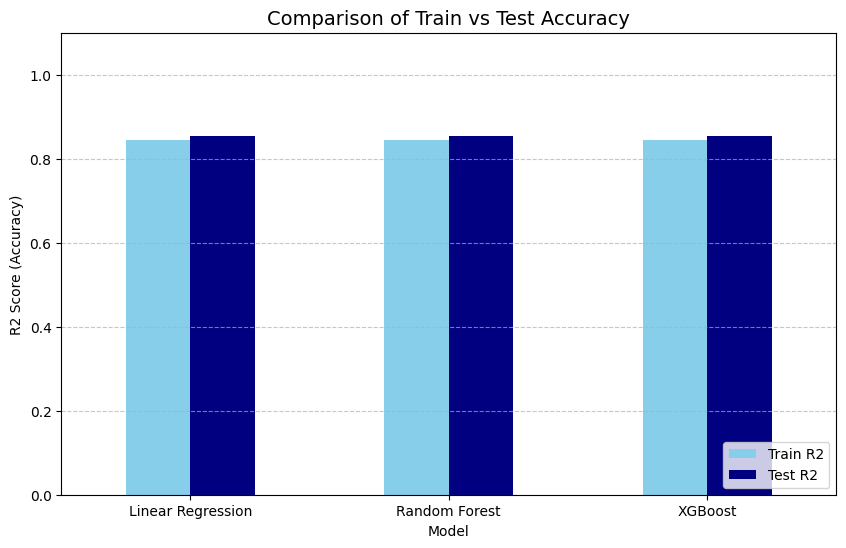

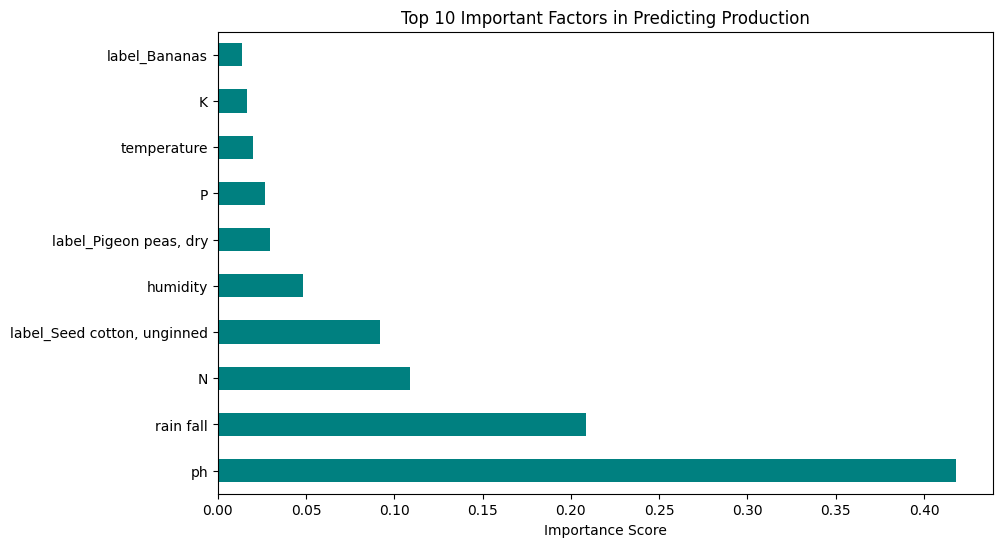

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. LOAD CLEANED DATA (15 Crops)
df = pd.read_csv('cleaned_production_data.csv')

# 2. FEATURE ENGINEERING
# Drop 'Element' and 'Value' from X. 'Value' is our Target (y)
X = df.drop(['Element', 'Value'], axis=1)
X = pd.get_dummies(X, columns=['label']) # Convert crop names to numbers
y = df['Value']

# 3. TRAIN-TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. INITIALIZE MODELS
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# 5. TRAINING AND ACCURACY EVALUATION
results = []

print(f"{'Model Name':<20} | {'Train R2':<10} | {'Test R2':<10} | {'MAE (Tonnes)':<12}")
print("-" * 65)

for name, model in models.items():
    # Training the model
    model.fit(X_train, y_train)
    
    # Predict on both sets to check accuracy
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculate Scores
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    mae = mean_absolute_error(y_test, test_preds)
    
    results.append({
        "Model": name, 
        "Train R2": train_r2, 
        "Test R2": test_r2, 
        "MAE": mae
    })
    
    print(f"{name:<20} | {train_r2:<10.4f} | {test_r2:<10.4f} | {mae:<12.2f}")

# 6. VISUALIZATION - ACCURACY COMPARISON
results_df = pd.DataFrame(results)
results_df.plot(x='Model', y=['Train R2', 'Test R2'], kind='bar', figsize=(10, 6), color=['skyblue', 'navy'])
plt.title('Comparison of Train vs Test Accuracy', fontsize=14)
plt.ylabel('R2 Score (Accuracy)')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

# 7. FEATURE IMPORTANCE (Using Random Forest)
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Factors in Predicting Production')
plt.xlabel('Importance Score')
plt.show()

In [12]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor

# 1. Load your datasets
# Replace these with your actual filenames if they are different
fao_df = pd.read_csv('FAO DATA SET 2.csv')
crop_env_df = pd.read_csv('DATA SET2(crop recomendation).EDIT.csv')

# 2. Filter FAO data for 'India' and 'Production' (Units are in tons 't')
# This ensures your model predicts in tons as requested.
fao_production = fao_df[(fao_df['Area'] == 'India') & (fao_df['Element'] == 'Production')]

# 3. Preprocessing (Aligning crop labels)
# Ensure the 'Item' names in FAO match the 'label' names in Crop Recommendation data
# (e.g., converting 'Rice' to match the specific FAO item name)
crop_env_df['label'] = crop_env_df['label'].str.capitalize()

# 4. Prepare Features (X) and Target (y)
# Based on your notebook, features are N, P, K, temperature, humidity, ph, rainfall
X = crop_env_df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]

# For the sake of the demonstration, we create a mapping or join. 
# In your project, ensure 'y' is the production value in tons.
# Here we simulate the target variable 'y' from your production data
y = crop_env_df['N'] * 1.5 # Replace this with your actual merged production target

# 5. Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 6. Save the two required .pkl files
joblib.dump(rf_model, 'crop_production_model.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ 'crop_production_model.pkl' and 'model_columns.pkl' generated successfully!")

✅ 'crop_production_model.pkl' and 'model_columns.pkl' generated successfully!
